### Đọc dữ liệu

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/raw_data.csv")

### Tiền xử lý

In [2]:
df.shape

(7043, 33)

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.nunique()

CustomerID           7043
Count                   1
Country                 1
State                   1
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6531
Churn Label             2
Churn Value             2
Churn Score            85
CLTV                 3438
Churn Reason           20
dtype: int64

- 3 cột: `Count`, `Country`, `State` có thể bỏ, vì tất cả đều có cùng 1 giá trị

In [5]:
df = df.drop(columns=["Count", "Country", "State" ])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   City               7043 non-null   object 
 2   Zip Code           7043 non-null   int64  
 3   Lat Long           7043 non-null   object 
 4   Latitude           7043 non-null   float64
 5   Longitude          7043 non-null   float64
 6   Gender             7043 non-null   object 
 7   Senior Citizen     7043 non-null   object 
 8   Partner            7043 non-null   object 
 9   Dependents         7043 non-null   object 
 10  Tenure Months      7043 non-null   int64  
 11  Phone Service      7043 non-null   object 
 12  Multiple Lines     7043 non-null   object 
 13  Internet Service   7043 non-null   object 
 14  Online Security    7043 non-null   object 
 15  Online Backup      7043 non-null   object 
 16  Device Protection  7043 

- Có 22 cột object
- Có 8 cột numeric

In [7]:
# kiểm tra các giá trị NAN
df.isnull().sum()

CustomerID              0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

- Chỉ có `Churn Reason` có 5174 giá trị NaN

In [8]:
# Trả về tổng số hàng bị trùng lặp
print(df.duplicated().sum())

0


In [9]:
# Thống kê của các cột numeric
df.describe()

,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [10]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

- Dataset khá mất cân bằng (số lượng bản ghi No gấp gần 3 lần Yes)
- Accuracy sẽ ko phải metric tốt nhất

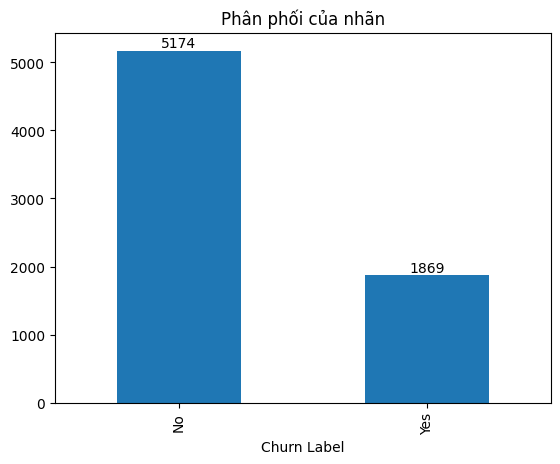

In [11]:
import matplotlib.pyplot as plt

ax = df["Churn Label"].value_counts().plot(kind="bar")
for container in ax.containers:
    ax.bar_label(container)
    
plt.title("Phân phối của nhãn")
plt.show()

In [12]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

- Khách hàng dùng Month-to-month chiếm đa số

In [13]:
df.groupby("Contract")["Churn Label"].value_counts()

Contract        Churn Label
Month-to-month  No             2220
                Yes            1655
One year        No             1307
                Yes             166
Two year        No             1647
                Yes              48
Name: count, dtype: int64

- Khách hàng dùng Month-to-month có tỷ lệ nghỉ ít hơn so với 2 loại kia

In [14]:
plt.style.use("ggplot")

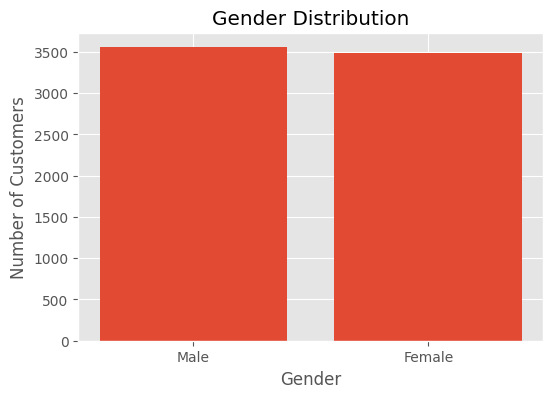

In [15]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(gender_counts.index, gender_counts.values)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

- Male và Female gần như cân bằng.
- Không thấy khác biệt lớn về churn.

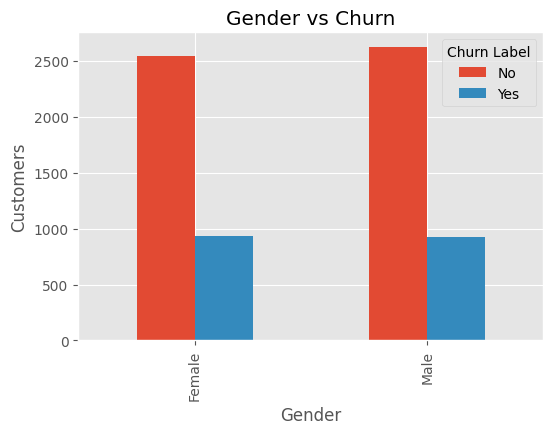

In [16]:
gender_churn = pd.crosstab(df["Gender"], df["Churn Label"])

gender_churn.plot(kind="bar", figsize=(6,4))

plt.title("Gender vs Churn")
plt.ylabel("Customers")

plt.show()

- Giới tính ko ảnh hưởng nhiều đến khả năng rời dịch vụ

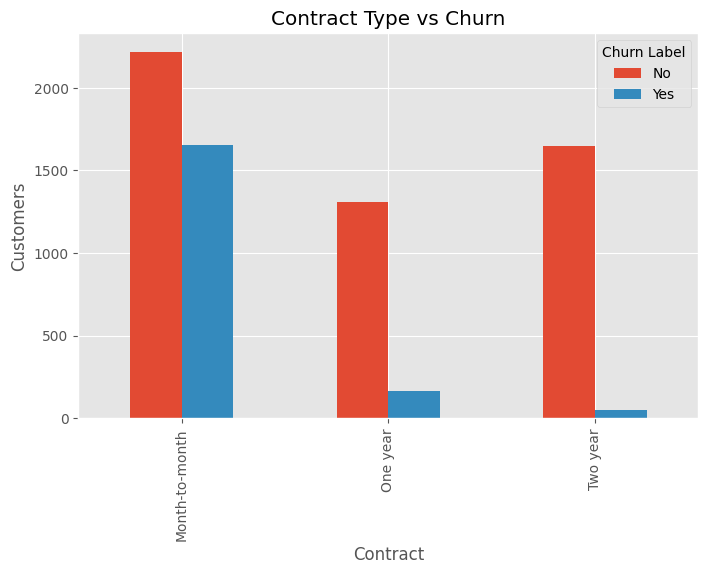

In [17]:
contract_churn = pd.crosstab(df["Contract"], df["Churn Label"])

contract_churn.plot(kind="bar", figsize=(8,5))

plt.title("Contract Type vs Churn")
plt.ylabel("Customers")

plt.show()

Month-to-month

↓

Có churn cao nhất.

- Hai loại hợp đồng còn lại thấp hơn đáng kể.
- Khách hàng ký hợp đồng dài hạn có xu hướng trung thành hơn

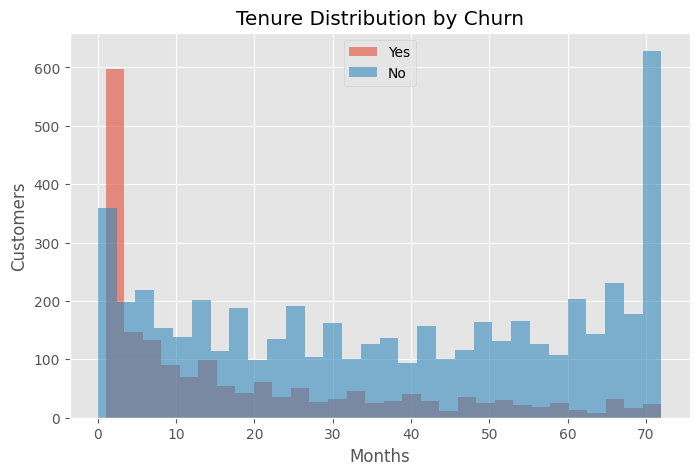

In [18]:
plt.figure(figsize=(8,5))

for churn in ["Yes", "No"]:
    subset = df[df["Churn Label"] == churn]
    plt.hist(
        subset["Tenure Months"],
        bins=30,
        alpha=0.6,
        label=churn
    )

plt.legend()
plt.title("Tenure Distribution by Churn")
plt.xlabel("Months")
plt.ylabel("Customers")

plt.show()

- Khách hàng mới sử dụng dịch vụ có xu hướng rời bỏ nhiều hơn

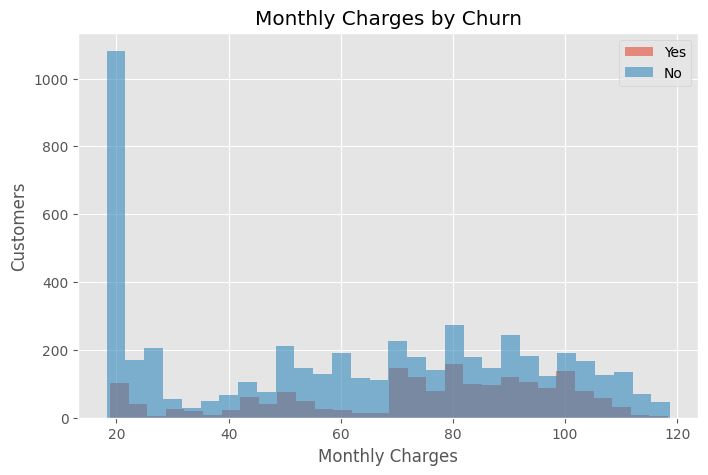

In [19]:
plt.figure(figsize=(8,5))

for churn in ["Yes", "No"]:
    subset = df[df["Churn Label"] == churn]
    plt.hist(
        subset["Monthly Charges"],
        bins=30,
        alpha=0.6,
        label=churn
    )

plt.legend()

plt.title("Monthly Charges by Churn")

plt.xlabel("Monthly Charges")

plt.ylabel("Customers")

plt.show()

- Những khách hàng phải trả phí hàng tháng cao có xu hướng rời bỏ nhiều hơn.

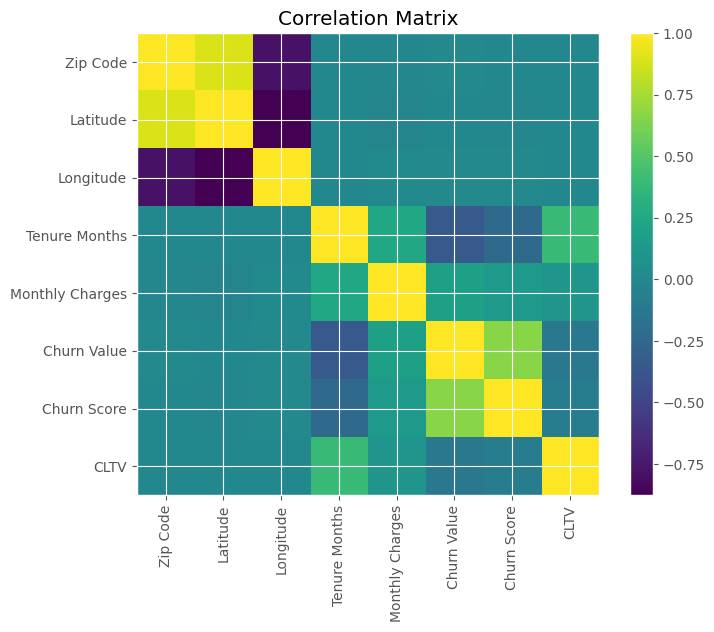

In [20]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr()
plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

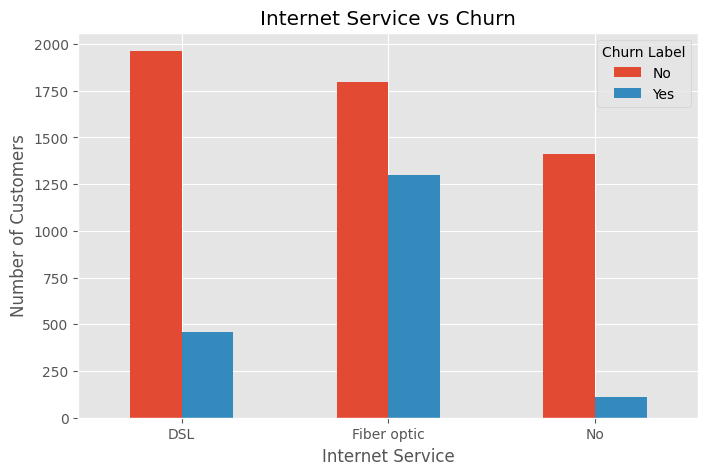

In [21]:
internet_churn = pd.crosstab(df["Internet Service"], df["Churn Label"])

internet_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()

- Customers using Fiber Optic Internet have a noticeably higher churn rate than DSL users.
- Possible reasons include higher monthly costs, stronger competition, or service quality expectations.

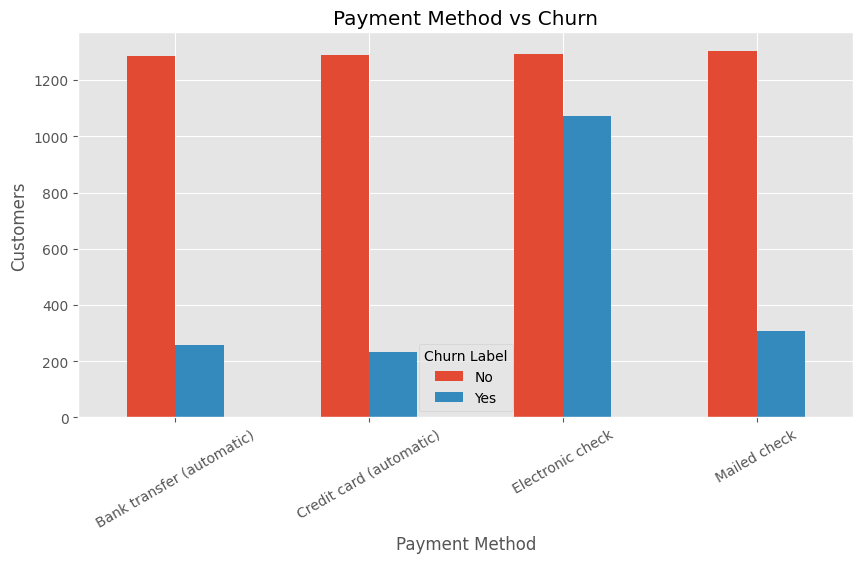

In [22]:
payment_churn = pd.crosstab(
    df["Payment Method"],
    df["Churn Label"]
)

payment_churn.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Payment Method vs Churn")

plt.ylabel("Customers")

plt.xticks(rotation=30)

plt.show()

- Customers using Electronic Check tend to have a higher churn rate than those using automatic payment methods.
- This suggests payment behavior may correlate with customer retention.

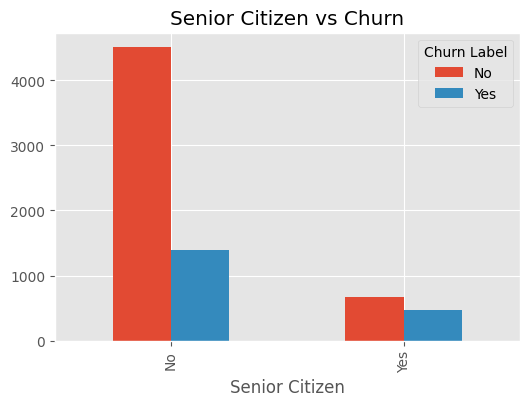

In [23]:
senior_churn = pd.crosstab(
    df["Senior Citizen"],
    df["Churn Label"]
)

senior_churn.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Senior Citizen vs Churn")

plt.show()

- Senior customers appear to have a slightly higher churn rate.
- This variable may contribute to the prediction model.

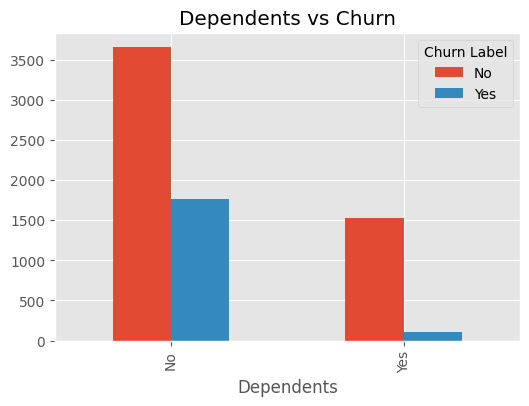

In [24]:
dependent_churn = pd.crosstab(
    df["Dependents"],
    df["Churn Label"]
)

dependent_churn.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Dependents vs Churn")

plt.show()

- Customers without dependents are more likely to leave the service.
- Having dependents may increase customer stability.

<Figure size 700x500 with 0 Axes>

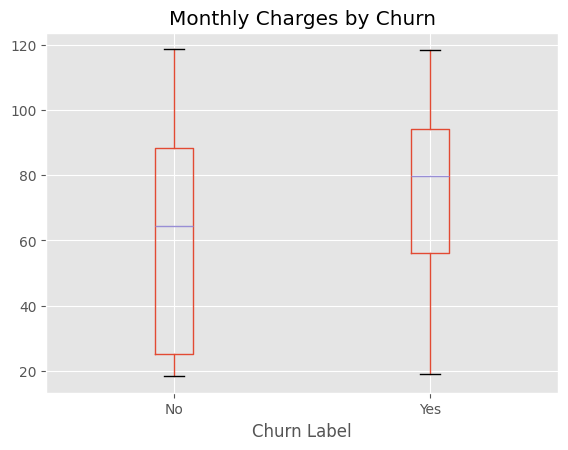

In [25]:
plt.figure(figsize=(7,5))

df.boxplot(
    column="Monthly Charges",
    by="Churn Label"
)

plt.title("Monthly Charges by Churn")

plt.suptitle("")

plt.show()

Main Findings

✓ Dataset has slight imbalance

✓ Contract strongly affects churn

✓ Tenure negatively correlates with churn

✓ Monthly Charges positively correlate with churn

✓ Gender seems unimportant

Next Sprint

Data Cleaning